In [1]:
from synthetic import *
from comparing import train
from train_models import *
import pandas as pd
import plotly.express as px

train_data = pd.read_csv("Dataset/synthetic_1x.csv")
X_test, y_test = create_synthetic_data(False)
X_train, y_train = train_data.drop(columns="Y"), train_data["Y"]

X_train, X_test = preprocess(X_train, X_test, y_train)

Accuracy: 0.71847739888977

Detaylı Sınıflandırma Raporu:
               precision    recall  f1-score   support

           0       0.72      0.57      0.64      1091
           1       0.72      0.83      0.77      1431

    accuracy                           0.72      2522
   macro avg       0.72      0.70      0.70      2522
weighted avg       0.72      0.72      0.71      2522

Confusion Matrix:
 [[ 626  465]
 [ 245 1186]]
ROC-AUC Skoru: 0.7622


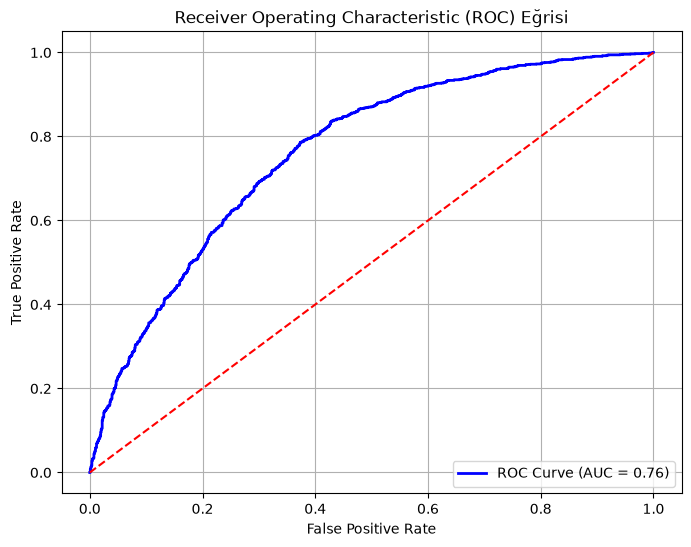

Logistic Regression ROC-AUC: 0.7375736683019253
Random Forest ROC-AUC: 0.7309186207461981
Support Vector Machine ROC-AUC: 0.7478873907025335
XGBoost ROC-AUC: 0.7544710197979658
AdaBoost ROC-AUC: 0.7460160989379466
LightGBM ROC-AUC: 0.7615388852699265
CatBoost ROC-AUC: 0.7652923577123291
ExtraTrees ROC-AUC: 0.6911788913933391
HistGradientBoosting ROC-AUC: 0.7601569540763287
Bagging ROC-AUC: 0.7232931788644914
Stacking ROC-AUC: 0.7627052800340247
Voting ROC-AUC: 0.7622268083762644


In [ ]:
lr_auc = train("Logistic Regression",X_train, X_test, y_train, y_test, False)
rf_auc = train("RandomForest",X_train, X_test, y_train, y_test, False)
svm_auc = train("Support Vector Machine",X_train, X_test, y_train, y_test, False)
xgb_auc = train("XGBoost",X_train, X_test, y_train, y_test, False)
adaB_auc = train("XAdaBoost",X_train, X_test, y_train, y_test, False)
LGBM_auc = train("LightGBM",X_train, X_test, y_train, y_test, False)
CB_auc = train("CatBoost",X_train, X_test, y_train, y_test, False)
ET_auc = train("ExtraTrees",X_train, X_test, y_train, y_test, False)
HGB_auc = train("HistGradientBoosting",X_train, X_test, y_train, y_test, False)
bagging_auc = train("Bagging",X_train, X_test, y_train, y_test, False)
stacking_auc = train("Stacking",X_train, X_test, y_train, y_test, True)
voting_auc = train("Voting",X_train, X_test, y_train, y_test, False)

print(f"Logistic Regression ROC-AUC: {lr_auc}")
print(f"Random Forest ROC-AUC: {rf_auc}")
print(f"Support Vector Machine ROC-AUC: {svm_auc}")
print(f"XGBoost ROC-AUC: {xgb_auc}")
print(f"AdaBoost ROC-AUC: {adaB_auc}")
print(f"LightGBM ROC-AUC: {LGBM_auc}")
print(f"CatBoost ROC-AUC: {CB_auc}")
print(f"ExtraTrees ROC-AUC: {ET_auc}")
print(f"HistGradientBoosting ROC-AUC: {HGB_auc}")
print(f"Bagging ROC-AUC: {bagging_auc}")
print(f"Stacking ROC-AUC: {stacking_auc}")
print(f"Voting ROC-AUC: {voting_auc}")

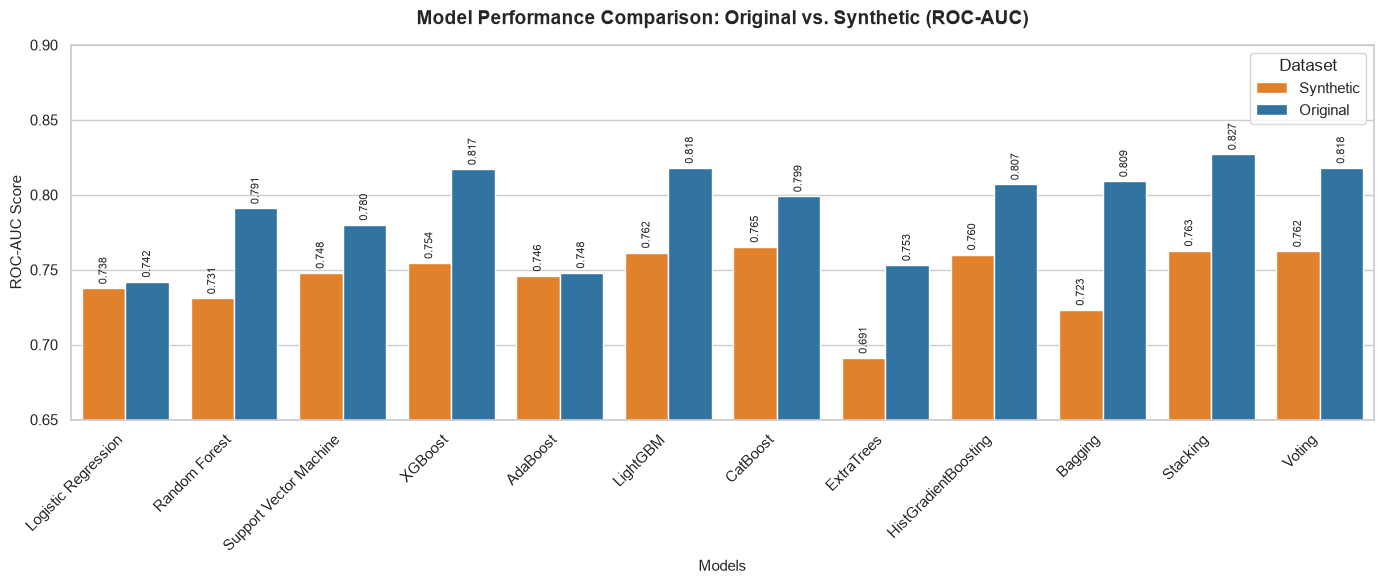

In [12]:
data = {
    'Model': [
        'Logistic Regression', 'Random Forest', 'Support Vector Machine', 
        'XGBoost', 'AdaBoost', 'LightGBM', 'CatBoost', 
        'ExtraTrees', 'HistGradientBoosting', 'Bagging', 'Stacking', 'Voting'
    ] * 2,
    'ROC-AUC': [
        # Sentetik Skorları
        0.73757, 0.73091, 0.74788, 0.75447, 0.74601, 
        0.76153, 0.76529, 0.69117, 0.76015, 0.72329, 0.76270, 0.76222,
        # Orijinal Skorları (Aşağıdaki değerleri kendi gerçek orijinal skorlarınla güncelleyebilirsin)
        0.742, 0.791, 0.780, 0.817, 0.748, 0.818, 0.799, 0.753, 0.807, 0.809, 
        0.827, 0.818
    ],
    'Dataset': ['Synthetic'] * 12 + ['Original'] * 12
}

df_results = pd.DataFrame(data)

plt.figure(figsize=(14, 6))
sns.set_theme(style='whitegrid')

# Seaborn ile gruplandırılmış çubuk grafik
ax = sns.barplot(
    x='Model', y='ROC-AUC', hue='Dataset', data=df_results, palette=['#ff7f0e', '#1f77b4']
)

# Etiketler ve düzenlemeler
plt.title(
    'Model Performance Comparison: Original vs. Synthetic (ROC-AUC)',
    fontsize=14,
    fontweight='bold',
    pad=15,
)
plt.xlabel('Models', fontsize=11)
plt.ylabel('ROC-AUC Score', fontsize=11)
plt.xticks(rotation=45, ha='right')
plt.legend(title='Dataset')
plt.ylim(0.65, 0.90)

# Çubukların üzerine değerleri yazdırma
for p in ax.patches:
    height = p.get_height()
    if height > 0:
        ax.annotate(
            f'{height:.3f}',
            (p.get_x() + p.get_width() / 2., height),
            ha='center',
            va='bottom',
            fontsize=8,
            rotation=90,
            xytext=(0, 3),
            textcoords='offset points',
        )

plt.tight_layout()
plt.show()

In [ ]:
data = X_train, X_test, y_train, y_test
train_model(data, stacking_best_roc_auc_params, model_type='stacking', best_metric="ROC-AUC", save=False)


=== FINAL TEST PERFORMANCE ===
Test ROC-AUC : 0.7558
Test F1      : 0.7608
Test Log Loss: 0.5774
Test Precision: 0.7119
Test Recall   : 0.8169


In [7]:
train_data = pd.read_csv("Dataset/synthetic_1x_medium_300_128.csv")
X_test, y_test = create_synthetic_data(False)
X_train, y_train = train_data.drop(columns="Y"), train_data["Y"]

X_train, X_test = preprocess(X_train, X_test, y_train)
data = X_train, X_test, y_train, y_test
train_model(data, stacking_best_roc_auc_params, model_type='stacking', best_metric="ROC-AUC", save=False)


=== FINAL TEST PERFORMANCE ===
Test ROC-AUC : 0.7701
Test F1      : 0.7473
Test Log Loss: 0.5710
Test Precision: 0.7346
Test Recall   : 0.7603


In [ ]:
X_test, y_test = create_synthetic_data(True,"medium",600,0.1,128)
train_data = pd.read_csv("Dataset/synthetic_1x_medium_600_128.csv")
X_train, y_train = train_data.drop(columns="Y"), train_data["Y"]

X_train, X_test = preprocess(X_train, X_test, y_train)
data = X_train, X_test, y_train, y_test
train_model(data, stacking_best_roc_auc_params, model_type='stacking', best_metric="ROC-AUC", save=False)


=== FINAL TEST PERFORMANCE ===
Test ROC-AUC : 0.7667
Test F1      : 0.7440
Test Log Loss: 0.5727
Test Precision: 0.7357
Test Recall   : 0.7526


In [2]:
X_test, y_test = create_synthetic_data(True,"medium",300,0.1,128,128)
train_data = pd.read_csv("Dataset/synthetic_1x_medium_300_128_128.csv")
X_train, y_train = train_data.drop(columns="Y"), train_data["Y"]

X_train, X_test = preprocess(X_train, X_test, y_train)
data = X_train, X_test, y_train, y_test
train_model(data, stacking_best_roc_auc_params, model_type='stacking', best_metric="ROC-AUC", save=False)


=== FINAL TEST PERFORMANCE ===
Test ROC-AUC : 0.7645
Test F1      : 0.7735
Test Log Loss: 0.5721
Test Precision: 0.7117
Test Recall   : 0.8470


In [5]:
data = pd.read_csv("Dataset/in-vehicle-coupon-recommendation.csv")
X_train, _, y_train, _ = create_train_test_datasets(data,create_features=False)
original_data = pd.concat([X_train, y_train], axis=1)

synthetic_default = pd.read_csv("Dataset/synthetic_1x.csv")
synthetic_v1 = pd.read_csv("Dataset/synthetic_1x_medium_300_128.csv")
synthetic_v2 = pd.read_csv("Dataset/synthetic_1x_medium_600_128.csv")
synthetic_v3 = pd.read_csv("Dataset/synthetic_1x_medium_300_128_128.csv")

target_report = target_relationship_diff(original_data, synthetic_default, target_col="Y")
print(target_report)

                  column  real_mi_with_target  synth_mi_with_target   mi_diff
5                 coupon             0.031585              0.025951  0.005634
0            destination             0.010434              0.006247  0.004187
15           CoffeeHouse             0.010710              0.006939  0.003771
6             expiration             0.013116              0.009426  0.003690
9          maritalStatus             0.001690              0.003535  0.001846
18      Restaurant20To50             0.003525              0.002013  0.001512
4                   time             0.006199              0.005257  0.000942
1              passanger             0.010573              0.009694  0.000879
12            occupation             0.002967              0.002130  0.000836
13                income             0.001541              0.002232  0.000691
17  RestaurantLessThan20             0.001147              0.000456  0.000691
10          has_children             0.001716              0.002

In [6]:
target_report = target_relationship_diff(original_data, synthetic_v1, target_col="Y")
print(target_report)

                  column  real_mi_with_target  synth_mi_with_target   mi_diff
5                 coupon             0.031585              0.024256  0.007329
6             expiration             0.013116              0.007608  0.005508
15           CoffeeHouse             0.010710              0.006179  0.004531
20     toCoupon_GEQ25min             0.011137              0.007386  0.003752
2                weather             0.008035              0.005291  0.002743
0            destination             0.010434              0.007901  0.002533
9          maritalStatus             0.001690              0.003992  0.002302
12            occupation             0.002967              0.005180  0.002213
10          has_children             0.001716              0.003787  0.002072
3            temperature             0.003027              0.002129  0.000898
19     toCoupon_GEQ15min             0.005330              0.006189  0.000859
17  RestaurantLessThan20             0.001147              0.002

In [3]:
X_test, y_test = create_synthetic_data("increased_early_stop",True,300,0.1,8,64)
train_data = pd.read_csv("Dataset/synthetic_1x_increased_early_stop.csv")
X_train, y_train = train_data.drop(columns="Y"), train_data["Y"]

X_train, X_test = preprocess(X_train, X_test, y_train)
data = X_train, X_test, y_train, y_test
train_model(data, stacking_best_roc_auc_params, model_type='stacking', best_metric="ROC-AUC", save=False)


=== FINAL TEST PERFORMANCE ===
Test ROC-AUC : 0.7580
Test F1      : 0.7576
Test Log Loss: 0.5774
Test Precision: 0.7217
Test Recall   : 0.7973


0.7579545112447245

In [7]:
X_test, y_test = create_synthetic_data("increased_dropout",False,300,0.2,4,64)
train_data = pd.read_csv("Dataset/synthetic_1x_increased_dropout.csv")
X_train, y_train = train_data.drop(columns="Y"), train_data["Y"]

X_train, X_test = preprocess(X_train, X_test, y_train)
data = X_train, X_test, y_train, y_test
train_model(data, stacking_best_roc_auc_params, model_type='stacking', best_metric="ROC-AUC", save=False)


=== FINAL TEST PERFORMANCE ===
Test ROC-AUC : 0.7712
Test F1      : 0.7483
Test Log Loss: 0.5695
Test Precision: 0.7406
Test Recall   : 0.7561


0.771215926508803

In [8]:
X_test, y_test = create_synthetic_data("early_stop_6",True,300,0.2,6,64)
train_data = pd.read_csv("Dataset/synthetic_1x_early_stop_6.csv")
X_train, y_train = train_data.drop(columns="Y"), train_data["Y"]

X_train, X_test = preprocess(X_train, X_test, y_train)
data = X_train, X_test, y_train, y_test
train_model(data, stacking_best_roc_auc_params, model_type='stacking', best_metric="ROC-AUC", save=False)


=== FINAL TEST PERFORMANCE ===
Test ROC-AUC : 0.7742
Test F1      : 0.7602
Test Log Loss: 0.5628
Test Precision: 0.7207
Test Recall   : 0.8043


0.7742417633377978

In [9]:
X_test, y_test = create_synthetic_data("increase_embeddind_dim",True,300,0.2,6,96)
train_data = pd.read_csv("Dataset/synthetic_1x_increase_embeddind_dim.csv")
X_train, y_train = train_data.drop(columns="Y"), train_data["Y"]

X_train, X_test = preprocess(X_train, X_test, y_train)
data = X_train, X_test, y_train, y_test
train_model(data, stacking_best_roc_auc_params, model_type='stacking', best_metric="ROC-AUC", save=False)


=== FINAL TEST PERFORMANCE ===
Test ROC-AUC : 0.7726
Test F1      : 0.7545
Test Log Loss: 0.5675
Test Precision: 0.7416
Test Recall   : 0.7680


0.7725924132457866

In [2]:
X_test, y_test = create_synthetic_data("increase_embeddind_dim",True,300,0.2,6,64,2)
train_data = pd.read_csv("Dataset/synthetic_1x_increase_embeddind_dim.csv")
X_train, y_train = train_data.drop(columns="Y"), train_data["Y"]

X_train, X_test = preprocess(X_train, X_test, y_train)
data = X_train, X_test, y_train, y_test
train_model(data, stacking_best_roc_auc_params, model_type='stacking', best_metric="ROC-AUC", save=False)


=== FINAL TEST PERFORMANCE ===
Test ROC-AUC : 0.7719
Test F1      : 0.7619
Test Log Loss: 0.5658
Test Precision: 0.7160
Test Recall   : 0.8141


0.7718686207782243